# Eval Output Analysis

Load outputs from `eval_scripts/eval_full_metrics_new.py`, plot metrics that are naturally plottable, show the remaining metrics in tables, and inspect generated trajectories with the existing py3Dmol helpers.

In [1]:
from pathlib import Path
import json
import math
import sys

import numpy as np
import pandas as pd
import torch
import matplotlib.pyplot as plt
from IPython.display import display
from torchmetrics import MetricCollection

_REPO_ROOT = Path.cwd()
if _REPO_ROOT.name == "notebooks":
    _REPO_ROOT = _REPO_ROOT.parent
if str(_REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(_REPO_ROOT))

from notebooks.utils import (
    load_tokens,
    process_mol,
    visualize_single_mol,
    visualize_variable_topology,
)
from chemflow.dataset.vocab import Distributions
from chemflow.dataset.molecule_data import MoleculeBatch
from chemflow.utils.batch_metrics import build_batch_metrics, build_batch_marginal_plots
from chemflow.utils.utils import index_to_token
from chemflow.utils import rdkit_utils as chemflowRD

plt.style.use("default")
pd.set_option("display.max_rows", 200)
pd.set_option("display.max_columns", 50)

/home/mila/g/goldszaa/scratch/chemflow/.venv/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## Configure Paths

Set `OUTPUT_DIR` to the folder produced by the eval script. For example:

```bash
eval_outputs/qm9_pointcloud_300
```

In [2]:
REPO_ROOT = _REPO_ROOT

OUTPUT_DIR = REPO_ROOT / "eval_outputs" / "qm9_pointcloud_300"
TOKEN_DIR = REPO_ROOT / "data" / "qm9" / "processed"

assert OUTPUT_DIR.exists(), f"Missing output dir: {OUTPUT_DIR}"
assert (OUTPUT_DIR / "results.json").exists(), f"Missing results.json in {OUTPUT_DIR}"

OUTPUT_DIR

PosixPath('/network/scratch/g/goldszaa/chemflow/eval_outputs/qm9_pointcloud_300')

## Load Metrics

In [3]:
with (OUTPUT_DIR / "results.json").open("r", encoding="utf-8") as f:
    summary = json.load(f)

seeds = [int(s) for s in summary["seeds"]]
representation = summary.get("representation", "unknown")
per_seed = summary["per_seed_metrics"]
aggregated = summary["aggregated"]

per_seed_df = pd.DataFrame.from_dict(per_seed, orient="index")
per_seed_df.index.name = "seed"
per_seed_df = per_seed_df.apply(pd.to_numeric, errors="coerce")

agg_df = pd.DataFrame.from_dict(aggregated, orient="index")
agg_df.index.name = "metric"

print(f"representation: {representation}")
print(f"seeds: {seeds}")
print(f"checkpoint: {summary.get('checkpoint')}")
display(per_seed_df)
display(agg_df[["mean", "std", "n_seeds_used"]].sort_index())

representation: pointcloud
seeds: [42]
checkpoint: outputs/qm9/uncond/2026-05-13/zbnp6nvq/every_n_epochs/epoch=64-step=6305.ckpt


,batch/atom_count_marginal_kl,batch/atom_type_marginal_kl,batch/min_dist_violation,batch/pair_dist_l1,batch/range_overflow,batch/rog_l1,n_total,n_valid_final,n_rdkit_parseable
seed,,,,,,,,,
42,0.084109,0.003136,0.0,0.49544,0.0,0.264353,300.0,0.0,0.0


,mean,std,n_seeds_used
metric,,,
batch/atom_count_marginal_kl,0.084109,NaN,1
batch/atom_type_marginal_kl,0.003136,NaN,1
batch/min_dist_violation,0.000000,NaN,1
batch/pair_dist_l1,0.495440,NaN,1
batch/range_overflow,0.000000,NaN,1
batch/rog_l1,0.264353,NaN,1
n_rdkit_parseable,0.000000,NaN,1
n_total,300.000000,NaN,1
n_valid_final,0.000000,NaN,1


## Plot Metric Groups

The batch metrics are tensor/geometric metrics and exist for pointcloud and graph runs. RDKit metrics are only meaningful for `geometric_graph` runs.

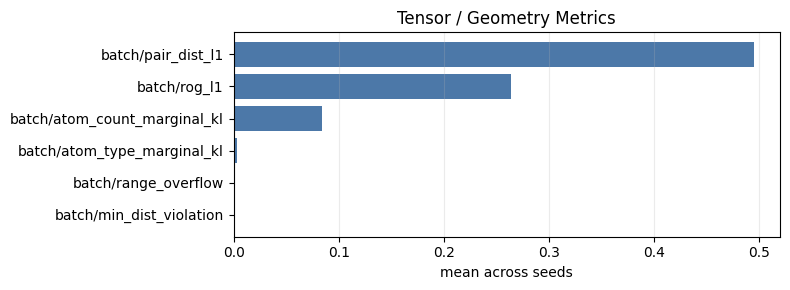

No finite metrics to plot for: RDKit Metrics


In [4]:
def _finite_mean(metric_name):
    row = aggregated.get(metric_name, {})
    value = row.get("mean", float("nan"))
    return value if isinstance(value, (int, float)) and math.isfinite(value) else np.nan


def plot_metric_bars(metric_names, title, *, sort=True):
    values = pd.Series({name: _finite_mean(name) for name in metric_names}).dropna()
    if values.empty:
        print(f"No finite metrics to plot for: {title}")
        return values
    if sort:
        values = values.sort_values()

    fig_height = max(3.0, 0.38 * len(values))
    fig, ax = plt.subplots(figsize=(8, fig_height))
    ax.barh(values.index, values.values, color="#4C78A8")
    ax.set_title(title)
    ax.set_xlabel("mean across seeds")
    ax.grid(axis="x", alpha=0.25)
    plt.tight_layout()
    plt.show()
    return values


all_metric_names = list(aggregated.keys())
batch_metric_names = [m for m in all_metric_names if m.startswith("batch/")]
count_metric_names = [m for m in all_metric_names if m.startswith("n_")]
rdkit_metric_names = [
    m
    for m in all_metric_names
    if not m.startswith("batch/") and not m.startswith("n_")
]

batch_values = plot_metric_bars(batch_metric_names, "Tensor / Geometry Metrics")
rdkit_values = plot_metric_bars(rdkit_metric_names, "RDKit Metrics")

## Metric Tables

In [5]:
summary_table = agg_df[["mean", "std", "n_seeds_used"]].copy()
summary_table["mean"] = pd.to_numeric(summary_table["mean"], errors="coerce")
summary_table["std"] = pd.to_numeric(summary_table["std"], errors="coerce")

print("Count / bookkeeping metrics")
display(summary_table.loc[[m for m in summary_table.index if m.startswith("n_")]])

print("All finite metrics")
display(summary_table[summary_table["mean"].map(np.isfinite)].sort_index())

print("Metrics without finite values")
display(summary_table[~summary_table["mean"].map(np.isfinite)].sort_index())

Count / bookkeeping metrics


,mean,std,n_seeds_used
metric,,,
n_rdkit_parseable,0.0,NaN,1
n_total,300.0,NaN,1
n_valid_final,0.0,NaN,1


All finite metrics


,mean,std,n_seeds_used
metric,,,
batch/atom_count_marginal_kl,0.084109,NaN,1
batch/atom_type_marginal_kl,0.003136,NaN,1
batch/min_dist_violation,0.000000,NaN,1
batch/pair_dist_l1,0.495440,NaN,1
batch/range_overflow,0.000000,NaN,1
batch/rog_l1,0.264353,NaN,1
n_rdkit_parseable,0.000000,NaN,1
n_total,300.000000,NaN,1
n_valid_final,0.000000,NaN,1


Metrics without finite values


,mean,std,n_seeds_used
metric,,,


## Atom Count Trajectories

rows = generations, cols = integration steps
n trajectories: 300, n frames: 200


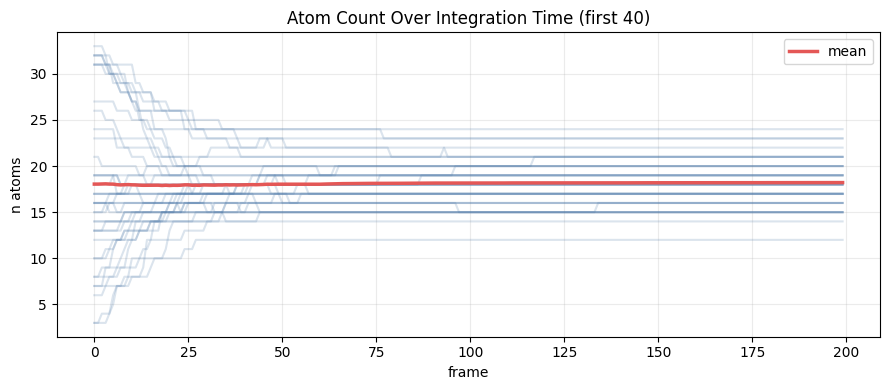

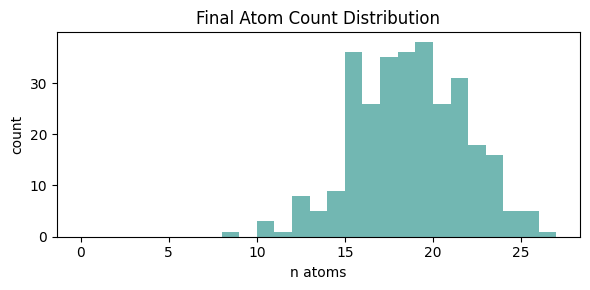

In [6]:
SEED = seeds[0]
natoms_path = OUTPUT_DIR / f"natoms_traj_seed{SEED}.pt"
natoms_payload = torch.load(natoms_path, weights_only=False)
natoms = natoms_payload["n_atoms_trajectories"]

if isinstance(natoms, torch.Tensor):
    natoms_arr = natoms.cpu().numpy()
else:
    max_len = max(len(x) for x in natoms)
    natoms_arr = np.full((len(natoms), max_len), np.nan)
    for i, seq in enumerate(natoms):
        natoms_arr[i, : len(seq)] = seq

print(natoms_payload.get("shape_note", ""))
print(f"n trajectories: {natoms_arr.shape[0]}, n frames: {natoms_arr.shape[1]}")

n_show = min(40, natoms_arr.shape[0])
fig, ax = plt.subplots(figsize=(9, 4))
for row in natoms_arr[:n_show]:
    ax.plot(row, alpha=0.2, color="#4C78A8")
ax.plot(np.nanmean(natoms_arr, axis=0), color="#E45756", lw=2.5, label="mean")
ax.set_title(f"Atom Count Over Integration Time (first {n_show})")
ax.set_xlabel("frame")
ax.set_ylabel("n atoms")
ax.grid(alpha=0.25)
ax.legend()
plt.tight_layout()
plt.show()

final_counts = natoms_arr[:, -1]
fig, ax = plt.subplots(figsize=(6, 3))
ax.hist(final_counts[~np.isnan(final_counts)], bins=range(int(np.nanmax(final_counts)) + 2), color="#72B7B2")
ax.set_title("Final Atom Count Distribution")
ax.set_xlabel("n atoms")
ax.set_ylabel("count")
plt.tight_layout()
plt.show()

## Load Trajectories For Visualization

In [7]:
traj_path = OUTPUT_DIR / f"trajectories_seed{SEED}.pt"
traj_payload = torch.load(traj_path, weights_only=False)
trajectories = traj_payload["all_trajectories"]
is_valid_final = traj_payload["is_valid_final"].cpu().numpy()

atom_tokens, edge_tokens, charge_tokens, distributions_raw = load_tokens(str(TOKEN_DIR))

def normalize_distributions(d):
    """Accept old dict caches and newer Distributions objects."""
    if isinstance(d, Distributions):
        return d
    if not isinstance(d, dict):
        return d
    return Distributions(
        atom_type_distribution=torch.as_tensor(d["atom_type_distribution"]),
        edge_type_distribution=torch.as_tensor(d["edge_type_distribution"]),
        charge_type_distribution=torch.as_tensor(d["charge_type_distribution"]),
        n_atoms_distribution=torch.as_tensor(d["n_atoms_distribution"]),
        coordinate_std=torch.as_tensor(d["coordinate_std"]),
        pairwise_distance_histogram=(
            torch.as_tensor(d["pairwise_distance_histogram"])
            if d.get("pairwise_distance_histogram") is not None
            else None
        ),
        radius_of_gyration_histogram=(
            torch.as_tensor(d["radius_of_gyration_histogram"])
            if d.get("radius_of_gyration_histogram") is not None
            else None
        ),
    )

distributions = normalize_distributions(distributions_raw)

print(f"loaded trajectories: {len(trajectories)}")
print(f"valid final count: {int(is_valid_final.sum())}")
print(f"invalid / unchecked final count: {int((~is_valid_final).sum())}")

loaded trajectories: 300
valid final count: 0
invalid / unchecked final count: 300


## Training-Distribution Comparison Plots

These reuse the same tensor-side marginal plotting helpers used during validation. They compare generated final samples against the training-set distributions stored in `data/qm9/processed/distributions.pt`.

,value
atom_count_marginal_kl,0.084109
atom_type_marginal_kl,0.003136
min_dist_violation,0.000000
pair_dist_l1,0.495440
range_overflow,0.000000
rog_l1,0.264353


val/batch/plots/atom_count_marginal


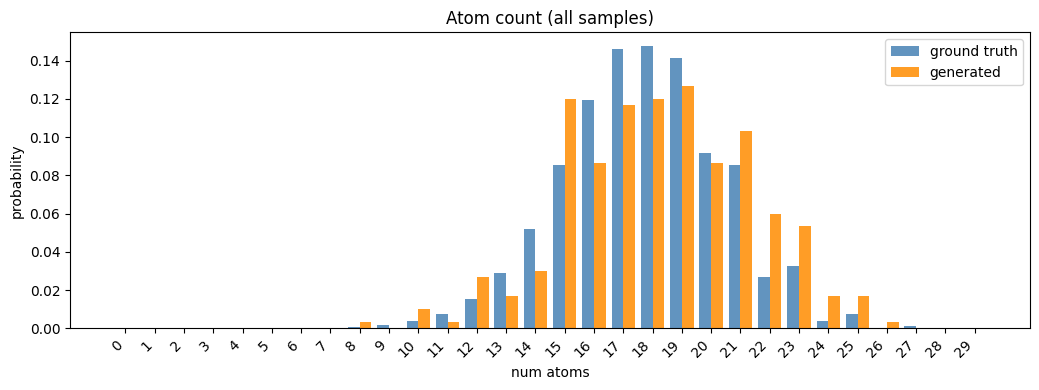

val/batch/plots/atom_type_marginal


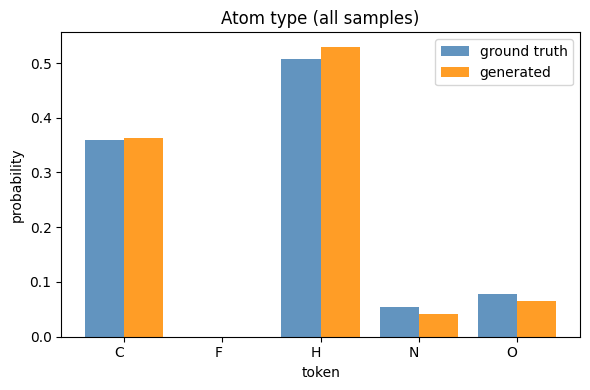

val/batch/plots/rog


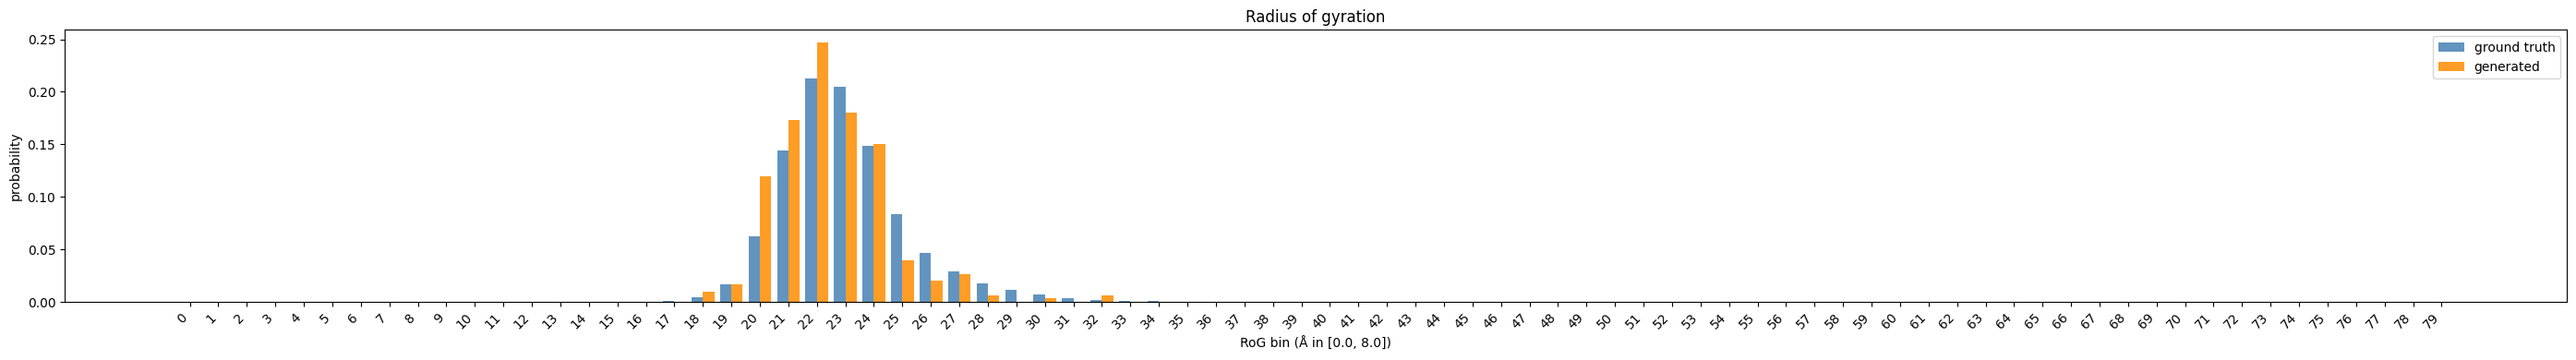

In [8]:
final_mols = [traj[-1] for traj in trajectories if len(traj) > 0]
final_batch = MoleculeBatch.from_data_list(final_mols)

batch_metric_dict = build_batch_metrics(distributions, len(atom_tokens))
if not batch_metric_dict:
    print("No tensor distribution targets found in distributions.pt. Rebuild preprocessing to enable these plots.")
else:
    comparison_metrics = MetricCollection(batch_metric_dict, compute_groups=False)
    comparison_metrics.update(final_batch)
    comparison_results = {
        k: float(v.item() if isinstance(v, torch.Tensor) else v)
        for k, v in comparison_metrics.compute().items()
    }
    display(pd.Series(comparison_results, name="value").to_frame())

    figs = build_batch_marginal_plots(comparison_metrics, atom_tokens=list(atom_tokens))
    for name, fig in figs.items():
        print(name)
        display(fig)
        plt.close(fig)

## Optional: Infer Bonds From Point Clouds

For pointcloud QM9 runs, generated edges are dummy runtime edges. RDKit can try to infer bonds from atom identities and 3D coordinates. Treat this as a geometry/chemistry diagnostic: it asks whether the point cloud can be perceived as a valid molecule, not whether the model generated a topology.

In [9]:
def pointcloud_to_rdkit_with_inferred_bonds(mol_data):
    atom_symbols = [index_to_token(atom_tokens, int(i)) for i in mol_data.a.cpu().tolist()]
    # Pointcloud QM9 is neutral by construction; this diagnostic ignores generated dummy c tokens.
    charges = np.zeros(len(atom_symbols), dtype=np.int64)
    coords = mol_data.x.detach().cpu().numpy()
    return chemflowRD.mol_from_atoms(
        coords=coords,
        tokens=atom_symbols,
        bonds=None,
        charges=charges,
        sanitise=True,
    )


inferred_rdkit = [pointcloud_to_rdkit_with_inferred_bonds(mol) for mol in final_mols]
inferred_parseable = [m is not None for m in inferred_rdkit]
inferred_valid = []
for mol in inferred_rdkit:
    if mol is None:
        inferred_valid.append(False)
        continue
    try:
        inferred_valid.append(chemflowRD.mol_is_valid(mol, allow_charged=False))
    except Exception:
        inferred_valid.append(False)

inferred_summary = pd.Series(
    {
        "n_total": len(inferred_rdkit),
        "n_rdkit_bond_inferred": int(sum(inferred_parseable)),
        "frac_rdkit_bond_inferred": float(np.mean(inferred_parseable)) if inferred_parseable else np.nan,
        "n_valid_after_inference": int(sum(inferred_valid)),
        "frac_valid_after_inference": float(np.mean(inferred_valid)) if inferred_valid else np.nan,
    },
    name="pointcloud_bond_inference",
)
display(inferred_summary.to_frame())

,pointcloud_bond_inference
n_total,300.00
n_rdkit_bond_inferred,261.00
frac_rdkit_bond_inferred,0.87
n_valid_after_inference,261.00
frac_valid_after_inference,0.87


## Visualize Inferred-Bond RDKit Molecule

This viewer uses RDKit's perceived bonds rather than the dummy pointcloud runtime edges.

In [10]:
import py3Dmol
from rdkit import Chem

valid_indices = [i for i, ok in enumerate(inferred_parseable) if ok]
if not valid_indices:
    print("No RDKit-perceived molecules to visualize.")
else:
    INFERRED_IDX = valid_indices[0]
    mol = inferred_rdkit[INFERRED_IDX]
    view = py3Dmol.view(
        data=Chem.MolToMolBlock(mol),
        width=700,
        height=450,
        style={"stick": {"radius": 0.12}, "sphere": {"scale": 0.25}},
    )
    view.zoomTo()
    view.show()

3Dmol.js failed to load for some reason. Please check your browser console for error messages.

## Visualize One Generated Trajectory

For pointcloud runs, edges are dummy `<NO_BOND>` runtime edges, so the viewer mostly shows atoms as spheres. For graph runs, bonds are shown when present.

In [11]:
TRAJ_IDX = 0
frames = [process_mol(m, atom_tokens, charge_tokens, edge_tokens) for m in trajectories[TRAJ_IDX]]

print(f"trajectory {TRAJ_IDX}: {len(frames)} frames")
print(f"final atoms: {len(frames[-1]['atoms'])}")

view = visualize_variable_topology(frames, interval=80, slider=True)
view.show()

trajectory 0: 200 frames
final atoms: 22


## Visualize Final Frame

In [12]:
final_view = visualize_single_mol(frames[-1], width=700, height=450)
final_view.show()

3Dmol.js failed to load for some reason. Please check your browser console for error messages.